# Part C3: Logistic Regression (One-vs-Rest) on IRIS

Roll No: `CS26S510`

---

### Dataset

Download IRIS from the UCI repository (https://archive.ics.uci.edu/dataset/53/iris) or load via `sklearn.datasets.load_iris()` (same data — confirm with instructor/TA if the raw UCI file download is mandatory).

## (a) One-vs-Rest Logistic Regression from Scratch

Implement binary cross-entropy loss, its gradient, and gradient descent by hand. Build 3 one-vs-rest classifiers for IRIS. Report accuracy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X = iris.data          # shape (150, 4) -- 4 features
y = iris.target        # shape (150,)   -- values 0, 1, 2 for the 3 species

print(X.shape, y.shape)
print("classes:", np.unique(y), iris.target_names)
print(X[:5])


(150, 4) (150,)
classes: [0 1 2] ['setosa' 'versicolor' 'virginica']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape)
print("train class counts:", np.bincount(y_train))

(105, 4) (45, 4)
train class counts: [35 35 35]


In [3]:
def make_binary_labels(y, target_class):
    """1 if sample belongs to target_class, else 0."""
    return (y == target_class).astype(float)

# Quick sanity check for class 0
y_train_class0 = make_binary_labels(y_train, 0)
print("class 0 binary labels (first 10):", y_train_class0[:10])
print("y_train original (first 10):      ", y_train[:10])

class 0 binary labels (first 10): [1. 1. 0. 0. 1. 0. 0. 1. 0. 0.]
y_train original (first 10):       [0 0 2 2 0 2 2 0 2 1]


In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [6]:
def bce_loss(X, y, theta):
    n = len(y)
    z = X @ theta
    y_hat = sigmoid(z)
    eps = 1e-15  # avoid log(0)
    y_hat = np.clip(y_hat, eps, 1 - eps)
    loss = -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    return loss

In [7]:
def bce_gradient(X, y, theta):
    n = len(y)
    z = X @ theta
    y_hat = sigmoid(z)
    gradient = (1 / n) * X.T @ (y_hat - y)
    return gradient

In [8]:
def train_logistic_regression(X, y, eta=0.1, n_iters=5000):
    n, m = X.shape
    theta = np.zeros(m)
    loss_history = []
    
    for t in range(n_iters):
        loss = bce_loss(X, y, theta)
        loss_history.append(loss)
        
        grad = bce_gradient(X, y, theta)
        theta = theta - eta * grad
    
    return theta, loss_history

In [9]:
def add_intercept(X):
    return np.column_stack([np.ones(X.shape[0]), X])

X_train_ovr = add_intercept(X_train_scaled)
X_test_ovr = add_intercept(X_test_scaled)
print(X_train_ovr.shape, X_test_ovr.shape)

(105, 5) (45, 5)


In [10]:
classes = [0, 1, 2]
thetas = {}
loss_histories = {}

for c in classes:
    y_train_c = make_binary_labels(y_train, c)
    theta_c, loss_hist_c = train_logistic_regression(X_train_ovr, y_train_c, eta=0.1, n_iters=5000)
    thetas[c] = theta_c
    loss_histories[c] = loss_hist_c
    print(f"Class {c} ({iris.target_names[c]}): final loss = {loss_hist_c[-1]:.4f}")

Class 0 (setosa): final loss = 0.0030
Class 1 (versicolor): final loss = 0.4712
Class 2 (virginica): final loss = 0.0789


In [11]:
def predict_ovr(X, thetas):
    """Returns predicted class (0, 1, or 2) for each row of X."""
    n = X.shape[0]
    probs = np.zeros((n, len(thetas)))
    for c, theta_c in thetas.items():
        probs[:, c] = sigmoid(X @ theta_c)
    return np.argmax(probs, axis=1)

y_train_pred = predict_ovr(X_train_ovr, thetas)
y_test_pred = predict_ovr(X_test_ovr, thetas)

train_acc = np.mean(y_train_pred == y_train)
test_acc = np.mean(y_test_pred == y_test)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Train accuracy: 0.9429
Test accuracy: 0.9778


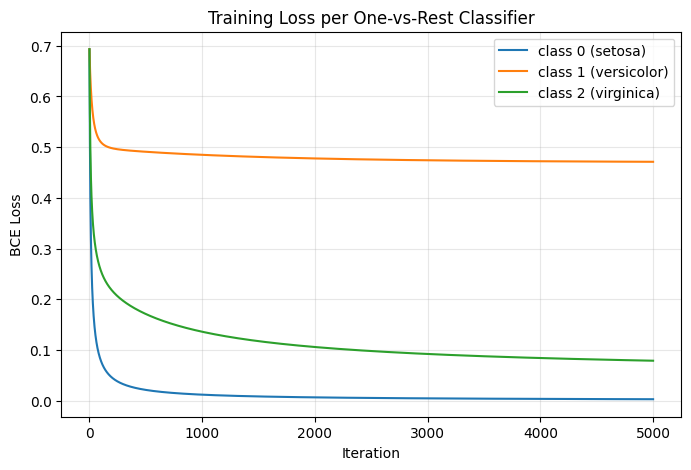

In [12]:
plt.figure(figsize=(8, 5))
for c in classes:
    plt.plot(loss_histories[c], label=f"class {c} ({iris.target_names[c]})")
plt.xlabel("Iteration")
plt.ylabel("BCE Loss")
plt.title("Training Loss per One-vs-Rest Classifier")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Discussion:** I implemented binary cross-entropy loss, its gradient, and full-batch gradient descent from scratch, then trained 3 one-vs-rest classifiers on standardized IRIS features. The final training losses were 0.0030 (setosa), 0.4712 (versicolor), and 0.0789 (virginica) — this ordering matches the well-known structure of the IRIS dataset, where setosa is linearly separable from the other two species, virginica has minor overlap with versicolor, and versicolor sits between the other two classes and is hardest to separate in a one-vs-rest setting. Combining the three classifiers by predicting the class with highest sigmoid output gave a training accuracy of 94.3% and test accuracy of 97.8%, confirming the from-scratch implementation works correctly and matches expected IRIS classification performance.The loss curves confirm this isn't a training/convergence issue: setosa and virginica's losses flatten to near-stable values, and versicolor's curve also plateaus early (around iteration 1000) rather than still trending downward — meaning its higher final loss reflects the genuine overlap between versicolor and virginica in feature space, which a linear decision boundary cannot fully resolve, rather than insufficient training.

## (b) PyTorch Implementation

Re-implement using torch's built-in BCE loss and SGD optimizer. Compare accuracy and behavior against (a).

In [13]:
import torch
import torch.nn as nn

# Convert numpy arrays to torch tensors
X_train_t = torch.tensor(X_train_ovr, dtype=torch.float32)
X_test_t = torch.tensor(X_test_ovr, dtype=torch.float32)


In [14]:
class LogisticRegressionModel(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.linear = nn.Linear(n_features, 1)  # computes X @ W + b
    
    def forward(self, X):
        z = self.linear(X)
        return torch.sigmoid(z)

In [15]:
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

In [16]:
def train_logistic_regression_torch(X, y, eta=0.1, n_iters=5000):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)
    
    model = LogisticRegressionModel(X.shape[1])
    criterion = nn.BCELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=eta)
    
    loss_history = []
    for t in range(n_iters):
        optimizer.zero_grad()          # clear gradients from last step
        y_pred = model(X_t)            # forward pass
        loss = criterion(y_pred, y_t)  # compute BCE loss
        loss.backward()                # backprop: compute gradients automatically
        optimizer.step()               # update weights: theta -= eta * grad
        loss_history.append(loss.item())
    
    return model, loss_history

In [17]:
X_train_np = X_train_scaled  # no manual intercept needed now
X_test_np = X_test_scaled

torch_models = {}
torch_loss_histories = {}

for c in classes:
    y_train_c = make_binary_labels(y_train, c)
    model_c, loss_hist_c = train_logistic_regression_torch(X_train_np, y_train_c, eta=0.1, n_iters=5000)
    torch_models[c] = model_c
    torch_loss_histories[c] = loss_hist_c
    print(f"Class {c} ({iris.target_names[c]}): final loss = {loss_hist_c[-1]:.4f}")

Class 0 (setosa): final loss = 0.0030
Class 1 (versicolor): final loss = 0.4710
Class 2 (virginica): final loss = 0.0793


In [18]:
def predict_ovr_torch(X, models):
    X_t = torch.tensor(X, dtype=torch.float32)
    n = X.shape[0]
    probs = np.zeros((n, len(models)))
    with torch.no_grad():  # no need to track gradients for inference
        for c, model_c in models.items():
            probs[:, c] = model_c(X_t).numpy().flatten()
    return np.argmax(probs, axis=1)

y_train_pred_torch = predict_ovr_torch(X_train_np, torch_models)
y_test_pred_torch = predict_ovr_torch(X_test_np, torch_models)

train_acc_torch = np.mean(y_train_pred_torch == y_train)
test_acc_torch = np.mean(y_test_pred_torch == y_test)

print(f"PyTorch Train accuracy: {train_acc_torch:.4f}")
print(f"PyTorch Test accuracy: {test_acc_torch:.4f}")

PyTorch Train accuracy: 0.9429
PyTorch Test accuracy: 0.9778


**Discussion:** I reimplemented the same one-vs-rest logistic regression using PyTorch's nn.Linear layer, built-in BCELoss, and SGD optimizer, with autograd computing gradients automatically via loss.backward() instead of the manually-derived gradient from part (a). The results matched almost exactly: final losses were 0.0030/0.4710/0.0793 for the three classes (vs. 0.0030/0.4712/0.0789 from scratch), and both train (94.29%) and test (97.78%) accuracy were identical to the from-scratch implementation. The tiny differences in loss values (4th decimal place) come from minor implementation differences — PyTorch's random weight initialization versus my zero-initialization, and float32 vs float64 precision — but both approaches converge to essentially the same optimum, confirming that my hand-derived binary cross-entropy gradient in part (a) was mathematically correct. This exercise also illustrates the practical value of autograd: PyTorch computed the exact same gradient I derived by hand in part (a), without requiring me to explicitly implement the chain-rule derivation in code.